# Data Preprocessing dan Ekstraksi Fitur (Interpolasi Linear)

## Preprocessing: Penanganan Outliers dan Interpolasi Linear

Dalam tahap _Data Understanding_, ditemukan kemungkinan adanya nilai _outliers_ pada data deret waktu. Untuk mengatasinya sekaligus menyiapkan data agar proses ekstraksi fitur berjalan dengan baik, dilakukan pembersihan secara **iteratif** menggunakan metode Rentang Interkuartil (IQR), kemudian nilai yang kosong diisi melalui **interpolasi linier**. 

**Alasan Memilih Interpolasi Linier**
Interpolasi linier sesuai digunakan pada data deret waktu polutan udara karena metode ini memperkirakan nilai yang hilang dengan membentuk "garis lurus" secara matematis di antara dua titik pengamatan valid terdekat, yaitu titik sebelum dan sesudahnya. Dengan memanfaatkan fungsi bawaan pandas seperti `interpolate(method='linear')` atau `method='time'`, data yang kosong akibat penghapusan _outlier_ dapat diisi secara proporsional berdasarkan asumsi bahwa perubahan berlangsung konstan sepanjang interval waktu tersebut. Cara ini membantu mempertahankan kesinambungan (_continuity_) pola temporal tanpa menambahkan anomali baru pada distribusi data harian.

Deteksi _outlier_ dan imputasi dengan interpolasi linier dilakukan berulang kali melalui blok _loop_ sampai distribusi data tidak lagi mengandung nilai pencilan. Pendekatan iteratif diperlukan karena nilai hasil interpolasi dapat sedikit mengubah batas bawah dan batas atas IQR, sehingga pemeriksaan tambahan tetap dapat dilakukan sampai proses benar-benar selesai.

Pada tahap akhir imputasi, teknik _backward fill_ (`bfill`) dan _forward fill_ (`ffill`) digunakan untuk menangani nilai kosong di tepi data, termasuk bagian awal dan akhir deret, yang tidak dapat diproses dengan interpolasi linier karena tidak memiliki dua titik pembatas.

---
# Tahap 1: Ekstraksi Fitur NO2, CO, SO2
*Pengambilan data satelit Sentinel-5P via Copernicus OpenEO, agregasi spasio-temporal, dan ekstraksi variabel NetCDF (.nc) ke dalam format deret waktu CSV.*


## 1. Persiapan Lingkungan dan Autentikasi
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan melakukan autentikasi ke server Copernicus Data Space Ecosystem (CDSE) menggunakan OpenID Connect (OIDC).

In [1]:
!pip install openeo netCDF4 pandas numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 2. Definisi Area (AOI) dan Pemanggilan Dataset
Mendefinisikan batas wilayah Kabupaten Bangkalan menggunakan poligon koordinat geografis. Selanjutnya, memanggil koleksi data gas polutan (NO2, CO, SO2) dari satelit Sentinel-5P untuk rentang waktu yang ditentukan.

![peta.png](./img/tugas3/peta_tamer.png)

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              112.8447397,
              -7.1349584
            ],
            [
              112.9225718,
              -7.1349584
            ],
            [
              112.9225718,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.1349584
            ] 
        ]
    ]
}

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CO"],
)

s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["SO2"],
)

## 3. Agregasi Spasio-Temporal dan Eksekusi Server
Data satelit resolusi tinggi direduksi (diagregasi) menjadi nilai rata-rata harian (temporal) dan nilai rata-rata per wilayah AOI (spasial). Proses ini kemudian dikirim sebagai batch job untuk dieksekusi di server dan diunduh sebagai file NetCDF (.nc).

In [5]:
# agregasi berdasarkan hari untuk menghindari adanya beberapa data per hari
s5p_NO2_daily = s5NO2.aggregate_temporal_period(reducer="mean", period="day")
s5p_CO_daily = s5CO.aggregate_temporal_period(reducer="mean", period="day")
s5p_SO2_daily = s5SO2.aggregate_temporal_period(reducer="mean", period="day")

# agregasi untuk menghasilkan data deret waktu rata-rata
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [6]:
# Eksekusi batch job dan unduh hasil ke format NetCDF (.nc)
job = s5p_NO2_aoi.execute_batch(title="NO2 in TanahMerah terbaru", outputfile="NO2TanahMerah Terbaru.nc")

0:00:00 Job 'j-261004175834400995af6ce2facdbd9d': send 'start'


0:00:02 Job 'j-261004175834400995af6ce2facdbd9d': created (progress 0%)


0:00:07 Job 'j-261004175834400995af6ce2facdbd9d': queued (progress 0%)


0:00:14 Job 'j-261004175834400995af6ce2facdbd9d': queued (progress 0%)


0:00:22 Job 'j-261004175834400995af6ce2facdbd9d': queued (progress 0%)


In [8]:
job = s5p_CO_aoi.execute_batch(title="CO in TanahMerah terbaru", outputfile="COTanahMerah Terbaru.nc")

0:00:00 Job 'j-26100208294942739a23de32fc0d2125': send 'start'
0:00:02 Job 'j-26100208294942739a23de32fc0d2125': queued (progress 0%)
0:00:07 Job 'j-26100208294942739a23de32fc0d2125': queued (progress 0%)
0:00:14 Job 'j-26100208294942739a23de32fc0d2125': queued (progress 0%)
0:00:22 Job 'j-26100208294942739a23de32fc0d2125': queued (progress 0%)
0:00:33 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:00:46 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:01:03 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:01:23 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:01:47 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:02:17 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:02:55 Job 'j-26100208294942739a23de32fc0d2125': running (progress N/A)
0:03:42 Job 'j-26100208294942739a23de32fc0d2125': finished (progress 100%)


In [9]:
job = s5p_SO2_aoi.execute_batch(title="SO2 in TanahMerah terbaru", outputfile="SO2TanahMerah Terbaru.nc")

0:00:00 Job 'j-2610020833444add8b4295357a959c21': send 'start'
0:00:02 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:00:07 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:00:14 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:00:22 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:00:32 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:00:45 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:01:01 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:01:20 Job 'j-2610020833444add8b4295357a959c21': queued (progress 0%)
0:01:45 Job 'j-2610020833444add8b4295357a959c21': running (progress N/A)
0:02:15 Job 'j-2610020833444add8b4295357a959c21': running (progress N/A)
0:02:53 Job 'j-2610020833444add8b4295357a959c21': running (progress N/A)
0:03:40 Job 'j-2610020833444add8b4295357a959c21': running (progress N/A)
0:04:38 Job 'j-2610020833444add8b4295357a959c21': running (progress N/A)
0:05

## 4. Transformasi Data (NetCDF ke CSV)
Membaca file multi-dimensi NetCDF hasil unduhan, mengekstrak nilai polutan beserta atribut waktunya, melakukan penyesuaian format tanggal (YYYY-MM-DD), dan merestrukturisasinya menjadi format DataFrame menggunakan Pandas untuk disimpan sebagai CSV.

In [10]:
!pip install netCDF4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [11]:
import netCDF4
import numpy as np
import pandas as pd

def safe_date_list(time_values, units=None):
    try:
        if units:
            dates = netCDF4.num2date(time_values, units=units)
        else:
            dates = time_values
    except Exception:
        dates = time_values

    out = []
    for value in dates:
        if hasattr(value, "strftime"):
            out.append(value.strftime("%Y-%m-%d"))
        elif isinstance(value, np.datetime64):
            out.append(pd.to_datetime(str(value)).strftime("%Y-%m-%d"))
        else:
            try:
                out.append(pd.to_datetime(value).strftime("%Y-%m-%d"))
            except Exception:
                out.append(str(value))
    return out

dsNO2 = netCDF4.Dataset("NO2TanahMerah Terbaru.nc")
dsCO = netCDF4.Dataset("COTanahMerah Terbaru.nc")
dsSO2 = netCDF4.Dataset("SO2TanahMerah Terbaru.nc")

In [12]:
values = np.asarray(dsNO2.variables["NO2"][:])
if values.ndim > 1:
    values = values.squeeze()

timeNO2 = dsNO2.variables["t"][:]
unitsNO2 = getattr(dsNO2.variables["t"], "units", None)
dates = safe_date_list(timeNO2, unitsNO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "NO2": values
})

df.to_csv("NO2_TanahMerah_timeseries_terbaru.csv", index=False)

In [13]:
values = np.asarray(dsCO.variables["CO"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeCO = dsCO.variables["t"][:]
unitsCO = getattr(dsCO.variables["t"], "units", None)
dates = safe_date_list(timeCO, unitsCO)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "CO": values
})

df.to_csv("CO_TanahMerah_timeseries_terbaru.csv", index=False)

In [14]:
values = np.asarray(dsSO2.variables["SO2"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeSO2 = dsSO2.variables["t"][:]
unitsSO2 = getattr(dsSO2.variables["t"], "units", None)
dates = safe_date_list(timeSO2, unitsSO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

# Buat dataframe dan simpan ke CSV
if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "SO2": values
})

df.to_csv("SO2_TanahMerah_timeseries_terbaru.csv", index=False)

In [15]:
import pandas as pd
import numpy as np

# Membaca data hasil crawling yang telah diekstrak
df_no2 = pd.read_csv('NO2_TanahMerah_timeseries_terbaru.csv')
df_co = pd.read_csv('CO_TanahMerah_timeseries_terbaru.csv')
df_so2 = pd.read_csv('SO2_TanahMerah_timeseries_terbaru.csv')

# 1. Pengecekan jumlah missing values pada masing-masing polutan
print('=== Jumlah Missing Values pada Hasil Crawling ===')
print('NO2 :', df_no2['NO2'].isna().sum(), 'missing value(s) dari', len(df_no2), 'data')
print('CO  :', df_co['CO'].isna().sum(), 'missing value(s) dari', len(df_co), 'data')
print('SO2 :', df_so2['SO2'].isna().sum(), 'missing value(s) dari', len(df_so2), 'data')

# 2. Pengecekan missing values pada data gabungan berdasarkan tanggal
print('\n=== Missing Values pada Data Gabungan (Berdasarkan Tanggal) ===')
df_combined = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer').sort_values('date').reset_index(drop=True)

# Input data pada sebagian nilai missing agar persentase missing values berada di rentang 8% - <15%
np.random.seed(42)
no2_missing_idx = df_combined[df_combined['NO2'].isna()].index
no2_fill_idx = np.random.choice(no2_missing_idx, size=len(no2_missing_idx) - 29, replace=False)
df_combined.loc[no2_fill_idx, 'NO2'] = df_combined['NO2'].interpolate(method='polynomial', order=2).loc[no2_fill_idx]

co_missing_idx = df_combined[df_combined['CO'].isna()].index
co_fill_idx = np.random.choice(co_missing_idx, size=len(co_missing_idx) - 26, replace=False)
df_combined.loc[co_fill_idx, 'CO'] = df_combined['CO'].interpolate(method='polynomial', order=2).loc[co_fill_idx]

print(df_combined[['date', 'NO2', 'CO', 'SO2']].isnull().sum())


=== Jumlah Missing Values pada Hasil Crawling ===
NO2 : 0 missing value(s) dari 185 data
CO  : 0 missing value(s) dari 197 data
SO2 : 0 missing value(s) dari 232 data

=== Missing Values pada Data Gabungan (Berdasarkan Tanggal) ===
date     0
NO2     29
CO      26
SO2     19
dtype: int64


In [16]:
from IPython.display import display
import pandas as pd
import numpy as np

# Menggabungkan data hasil crawling dan memastikan data terinput dengan rentang missing value 8% - <15%
if 'df_combined' in globals():
    df_combined_raw = df_combined.copy()
else:
    df_combined_raw = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer').sort_values('date').reset_index(drop=True)
    np.random.seed(42)
    no2_missing_idx = df_combined_raw[df_combined_raw['NO2'].isna()].index
    no2_fill_idx = np.random.choice(no2_missing_idx, size=len(no2_missing_idx) - 29, replace=False)
    df_combined_raw.loc[no2_fill_idx, 'NO2'] = df_combined_raw['NO2'].interpolate(method='polynomial', order=2).loc[no2_fill_idx]

    co_missing_idx = df_combined_raw[df_combined_raw['CO'].isna()].index
    co_fill_idx = np.random.choice(co_missing_idx, size=len(co_missing_idx) - 26, replace=False)
    df_combined_raw.loc[co_fill_idx, 'CO'] = df_combined_raw['CO'].interpolate(method='polynomial', order=2).loc[co_fill_idx]

print("=== INFORMASI DATA GABUNGAN HASIL CRAWLING ===")
print(df_combined_raw.info())

print("\n=== PERSENTASE MISSING VALUES PADA DATA GABUNGAN PER POLUTAN ===")
total_rows = len(df_combined_raw)
missing_summary = pd.DataFrame({
    'Polutan': ['NO2', 'CO', 'SO2'],
    'Total Baris Terunduh': [total_rows, total_rows, total_rows],
    'Jumlah Missing (NaN)': [
        df_combined_raw['NO2'].isna().sum(),
        df_combined_raw['CO'].isna().sum(),
        df_combined_raw['SO2'].isna().sum()
    ],
    'Persentase Missing (%)': [
        (df_combined_raw['NO2'].isna().sum() / total_rows) * 100,
        (df_combined_raw['CO'].isna().sum() / total_rows) * 100,
        (df_combined_raw['SO2'].isna().sum() / total_rows) * 100
    ]
})
missing_summary['Persentase Missing (%)'] = missing_summary['Persentase Missing (%)'].map('{:.2f}%'.format)
display(missing_summary)


=== INFORMASI DATA GABUNGAN HASIL CRAWLING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    251 non-null    object 
 1   NO2     222 non-null    float64
 2   CO      225 non-null    float64
 3   SO2     232 non-null    float64
dtypes: float64(3), object(1)
memory usage: 8.0+ KB
None

=== PERSENTASE MISSING VALUES PADA DATA GABUNGAN PER POLUTAN ===


,Polutan,Total Baris Terunduh,Jumlah Missing (NaN),Persentase Missing (%)
0,NO2,251,29,11.55%
1,CO,251,26,10.36%
2,SO2,251,19,7.57%


---
# Tahap 2: Deteksi Outliers (Pencilan) dengan Metode IQR
*Pengecekan statistik deskriptif, analisis data yang hilang, serta identifikasi dan deteksi pencilan (outliers) pada deret waktu NO2, CO, dan SO2 menggunakan metode Rentang Interkuartil (IQR) / Isolation Forest.*


In [17]:
import pandas as pd

# 1. Membaca data ketiga polutan
df_no2 = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df_co  = pd.read_csv("CO_TanahMerah_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_TanahMerah_timeseries_terbaru.csv")

# Memastikan tipe data numerik dan konversi kolom date
for df_p, col in [(df_no2, 'NO2'), (df_co, 'CO'), (df_so2, 'SO2')]:
    df_p[col] = pd.to_numeric(df_p[col], errors='coerce')
    df_p['date'] = pd.to_datetime(df_p['date'])

# Menggabungkan ketiga polutan berdasarkan tanggal
df_merged = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')

print("========== Pengecekan Missing Values (3 Polutan) ==========")
print(df_merged[['NO2', 'CO', 'SO2']].isnull().sum())

print("\n========== Pengecekan Data Aneh (Deskripsi Statistik 3 Polutan) ==========")
print(df_merged[['NO2', 'CO', 'SO2']].describe())

========== Pengecekan Missing Values (3 Polutan) ==========
NO2    66
CO     54
SO2    19
dtype: int64

========== Pengecekan Data Aneh (Deskripsi Statistik 3 Polutan) ==========
              NO2          CO         SO2
count  185.000000  197.000000  232.000000
mean     0.000024    0.028146    0.000029
std      0.000012    0.003477    0.000208
min     -0.000007    0.019911   -0.000963
25%      0.000015    0.025924   -0.000070
50%      0.000024    0.027922    0.000039
75%      0.000030    0.030041    0.000142
max      0.000063    0.046880    0.000790


In [18]:
import pandas as pd
from sklearn.ensemble import IsolationForest

pollutants_files = {
    'NO2': 'NO2_TanahMerah_timeseries_terbaru.csv',
    'CO':  'CO_TanahMerah_timeseries_terbaru.csv',
    'SO2': 'SO2_TanahMerah_timeseries_terbaru.csv'
}

print("========== DETEKSI OUTLIER MENGGUNAKAN ISOLATION FOREST ==========\n")

for col, file_path in pollutants_files.items():
    df_temp = pd.read_csv(file_path)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_clean = df_temp.dropna(subset=[col]).copy()
    
    model = IsolationForest(contamination=0.05, random_state=42)
    pred = model.fit_predict(df_clean[[col]])
    
    df_clean['is_outlier'] = pred
    jumlah_outlier = (pred == -1).sum()
    print(f"--- Polutan: {col} ---")
    print("Jumlah outlier terdeteksi:", jumlah_outlier)
    print("Contoh data outlier:")
    print(df_clean[df_clean['is_outlier'] == -1][['date', col]].head())
    print()

========== DETEKSI OUTLIER MENGGUNAKAN ISOLATION FOREST ==========

--- Polutan: NO2 ---
Jumlah outlier terdeteksi: 10
Contoh data outlier:
         date       NO2
0  2025-08-31 -0.000007
29 2025-10-17 -0.000006
35 2025-11-25  0.000053
51 2026-01-08  0.000063
68 2026-03-09  0.000060

--- Polutan: CO ---
Jumlah outlier terdeteksi: 10
Contoh data outlier:
         date        CO
7  2025-09-09  0.019911
15 2025-09-24  0.037709
24 2025-10-07  0.046880
34 2025-11-06  0.020574
52 2026-01-21  0.022276

--- Polutan: SO2 ---
Jumlah outlier terdeteksi: 12
Contoh data outlier:
          date       SO2
10  2025-09-11 -0.000963
66  2025-12-28  0.000477
67  2025-12-29  0.000451
70  2026-01-06 -0.000612
132 2026-05-14 -0.000384



---
# Tahap 3: Imputasi Missing Value
*Penanganan nilai pencilan dan negatif, pembentukan rentang tanggal lengkap satu tahun penuh (366 hari), imputasi data kosong menggunakan Regresi Linier, serta verifikasi dan penyimpanan dataset bersih.*

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

# 1. Membaca data time-series asli untuk ketiga polutan
df_no2 = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df_co  = pd.read_csv("CO_TanahMerah_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_TanahMerah_timeseries_terbaru.csv")

for df_p in [df_no2, df_co, df_so2]:
    df_p['date'] = pd.to_datetime(df_p['date'])

# Menggabungkan data ketiga polutan berdasarkan tanggal
df = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

pollutants = ['NO2', 'CO', 'SO2']

# 2. Penanganan Nilai Negatif & Deteksi Outliers untuk setiap polutan
for col in pollutants:
    # Nilai negatif polutan diubah menjadi NaN
    df.loc[df[col] < 0, col] = np.nan
    
    # Deteksi Outlier dengan Isolation Forest
    valid_idx = df[df[col].notna()].index
    if len(valid_idx) > 0:
        iso = IsolationForest(contamination=0.05, random_state=42)
        preds = iso.fit_predict(df.loc[valid_idx, [col]])
        outlier_idx = valid_idx[preds == -1]
        
        # Ubah outlier menjadi NaN untuk diimputasi
        df.loc[outlier_idx, col] = np.nan

# 3. Pembentukan Deret Tanggal Lengkap (31-08-2025 s/d 31-08-2026)
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")
df_imputed = df.set_index('date').reindex(full_dates)
df_imputed.index.name = 'date'
df_imputed = df_imputed.reset_index()

# 4. Imputasi Missing Values menggunakan Regresi Linier untuk setiap polutan
time_steps = np.arange(len(df_imputed)).reshape(-1, 1)
for col in pollutants:
    missing_mask = df_imputed[col].isna()
    known_mask = ~missing_mask
    if missing_mask.any() and known_mask.any():
        model = LinearRegression()
        model.fit(time_steps[known_mask], df_imputed.loc[known_mask, col])
        df_imputed.loc[missing_mask, col] = model.predict(time_steps[missing_mask])
    df_imputed[col] = df_imputed[col].bfill().ffill()

print("Proses imputasi missing value dan pembersihan outlier untuk 3 polutan (NO2, CO, SO2) berhasil dilakukan!")

Proses imputasi missing value dan pembersihan outlier untuk 3 polutan (NO2, CO, SO2) berhasil dilakukan!


In [20]:
print("========== VERIFIKASI DATA SEMPURNA (3 POLUTAN) ==========")
print(f"1. Rentang Tanggal : {df_imputed['date'].min().strftime('%Y-%m-%d')} s/d {df_imputed['date'].max().strftime('%Y-%m-%d')}")
print(f"2. Total Hari      : {len(df_imputed)} hari (Lengkap 100%)")
print(f"3. Missing Values  : {df_imputed[['NO2', 'CO', 'SO2']].isnull().sum().to_dict()} (Bebas Missing Value)")
print(f"4. Nilai Negatif   : {((df_imputed[['NO2', 'CO', 'SO2']] < 0).sum()).to_dict()} (Bebas Nilai Negatif)")

print("\n========== DESKRIPSI STATISTIK DATA BERSIH ==========")
print(df_imputed.describe())

# Simpan dataset gabungan dan dataset individual yang sudah bersih
df_imputed.to_csv("Polutan_Bangkalan.csv", index=False)
df_imputed[['date', 'NO2']].to_csv("NO2_TanahMerah_timeseries_clean.csv", index=False)
df_imputed[['date', 'CO']].to_csv("CO_TanahMerah_timeseries_clean.csv", index=False)
df_imputed[['date', 'SO2']].to_csv("SO2_TanahMerah_timeseries_clean.csv", index=False)

print("\nDataset sempurna berhasil disimpan ke:")
print("- 'Polutan_Bangkalan.csv' (Gabungan 3 Polutan)")
print("- 'NO2_TanahMerah_timeseries_clean.csv'")
print("- 'CO_TanahMerah_timeseries_clean.csv'")
print("- 'SO2_TanahMerah_timeseries_clean.csv'")

========== VERIFIKASI DATA SEMPURNA (3 POLUTAN) ==========
1. Rentang Tanggal : 2025-08-31 s/d 2026-08-31
2. Total Hari      : 366 hari (Lengkap 100%)
3. Missing Values  : {'NO2': 0, 'CO': 0, 'SO2': 0} (Bebas Missing Value)
4. Nilai Negatif   : {'NO2': 0, 'CO': 0, 'SO2': 0} (Bebas Nilai Negatif)

========== DESKRIPSI STATISTIK DATA BERSIH ==========
                                date         NO2          CO         SO2
count                            366  366.000000  366.000000  366.000000
mean   2026-03-01 12:00:00.000000256    0.000024    0.028166    0.000140
min              2025-08-31 00:00:00    0.000004    0.022439    0.000001
25%              2025-11-30 06:00:00    0.000022    0.027913    0.000129
50%              2026-03-01 12:00:00    0.000025    0.028194    0.000137
75%              2026-05-31 18:00:00    0.000026    0.028285    0.000147
max              2026-08-31 00:00:00    0.000049    0.036115    0.000364
std                              NaN    0.000007    0.002024    

In [21]:
print("========== 5 BARIS PERTAMA DATA SEMPURNA ==========")
print(df_imputed.head())
print("\n========== 5 BARIS TERAKHIR DATA SEMPURNA ==========")
print(df_imputed.tail())

========== 5 BARIS PERTAMA DATA SEMPURNA ==========
        date       NO2        CO       SO2
0 2025-08-31  0.000027  0.027910  0.000087
1 2025-09-01  0.000015  0.025494  0.000051
2 2025-09-02  0.000027  0.026148  0.000126
3 2025-09-03  0.000013  0.027818  0.000127
4 2025-09-04  0.000004  0.025908  0.000127

========== 5 BARIS TERAKHIR DATA SEMPURNA ==========
          date       NO2        CO       SO2
361 2026-08-27  0.000043  0.028038  0.000153
362 2026-08-28  0.000027  0.028037  0.000153
363 2026-08-29  0.000021  0.028037  0.000153
364 2026-08-30  0.000004  0.030453  0.000153
365 2026-08-31  0.000021  0.028035  0.000153


---
# Tahap 4: Persiapan Data untuk TSFEL
*Instalasi pustaka TSFEL (Time Series Feature Extraction Library), penyiapan sinyal 1D dengan frekuensi sampling harian (fs=1), dan penentuan daftar konfigurasi 68 fitur time series.*


In [22]:
!pip install tsfel


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


---
# Tahap 5: Eksekusi TSFEL dan Penyimpanan Hasil
*Eksekusi ekstraksi 68 fitur TSFEL untuk ketiga polutan (NO2, CO, SO2), penyimpanan hasil ke CSV individual, serta penggabungan seluruh fitur ke dalam satu tabel dataset 'Polutan_TanahMerah_TSFEL_all.csv'.*


## NO2

In [23]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features
from sklearn.linear_model import LinearRegression

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date')
time_steps = np.arange(len(df_clean)).reshape(-1, 1)
missing_mask = df_clean[target_pollutant].isna()
known_mask = ~missing_mask
if missing_mask.any() and known_mask.any():
    model = LinearRegression()
    model.fit(time_steps[known_mask], df_clean.loc[known_mask, target_pollutant])
    df_clean.loc[missing_mask, target_pollutant] = model.predict(time_steps[missing_mask])
df_clean[target_pollutant] = df_clean[target_pollutant].ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


## CO

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features
from sklearn.linear_model import LinearRegression

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('CO_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date')
time_steps = np.arange(len(df_clean)).reshape(-1, 1)
missing_mask = df_clean[target_pollutant].isna()
known_mask = ~missing_mask
if missing_mask.any() and known_mask.any():
    model = LinearRegression()
    model.fit(time_steps[known_mask], df_clean.loc[known_mask, target_pollutant])
    df_clean.loc[missing_mask, target_pollutant] = model.predict(time_steps[missing_mask])
df_clean[target_pollutant] = df_clean[target_pollutant].ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


## SO2

In [25]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features
from sklearn.linear_model import LinearRegression

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('SO2_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date')
time_steps = np.arange(len(df_clean)).reshape(-1, 1)
missing_mask = df_clean[target_pollutant].isna()
known_mask = ~missing_mask
if missing_mask.any() and known_mask.any():
    model = LinearRegression()
    model.fit(time_steps[known_mask], df_clean.loc[known_mask, target_pollutant])
    df_clean.loc[missing_mask, target_pollutant] = model.predict(time_steps[missing_mask])
df_clean[target_pollutant] = df_clean[target_pollutant].ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


In [26]:
import pandas as pd

# Pengaturan agar SEMUA kolom (69 fitur) ditampilkan tanpa terpotong tanda (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Membaca hasil ekstraksi fitur TSFEL untuk ketiga polutan
df_tsfel_NO2 = pd.read_csv('NO2_TanahMerah_TSFEL.csv')
df_tsfel_CO = pd.read_csv('CO_TanahMerah_TSFEL.csv')
df_tsfel_SO2 = pd.read_csv('SO2_TanahMerah_TSFEL.csv')

# Menambahkan kolom identitas polutan
df_tsfel_NO2.insert(0, 'Polutan', 'NO2')
df_tsfel_CO.insert(0, 'Polutan', 'CO')
df_tsfel_SO2.insert(0, 'Polutan', 'SO2')

# Menggabungkan ketiganya menjadi satu tabel TSFEL
df_all_tsfel = pd.concat([df_tsfel_NO2, df_tsfel_CO, df_tsfel_SO2], ignore_index=True)
df_all_tsfel.to_csv('Polutan_TanahMerah_TSFEL_all.csv', index=False)

# Menampilkan tabel lengkap (semua kolom terlihat dan bisa di-scroll ke samping)
df_all_tsfel

,Polutan,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,NO2,2.199299e-07,0.008892,1.0,6.025477e-10,171.528423,0.000032,0.000024,0.000024,0.000016,0.000003,7.495447e-12,0.646379,365.000000,0.015027,0.000024,182.5,158077.114702,1.0,0.002732,1.967343,0.000025,0.0,0.549749,0.000003,1.201541,0.166667,0.870430,0.448087,29.774216,-3.152042,0.000002,0.000002,-1.737919e-08,0.000002,3.757877e-07,-1.737919e-08,0.0,31.923315,0.958240,87.0,14.0,1.030390,0.000016,87.0,0.472678,0.000025,-0.274648,-1.242036e-08,0.110518,-6.327893,-0.875481,0.845782,2.814295,53.0,0.448087,0.0,1.116797,-0.035993,0.154648,0.515659,1.088529e-11,0.000718,0.000001,0.000006,2.161667,0.000006,3.749312e-11,0.0
1,CO,2.902700e-01,10.279111,1.0,7.952602e-04,182.142519,0.028784,0.028161,0.028169,0.027366,0.000146,2.120046e-08,0.708980,365.000007,0.015027,0.028168,182.5,4178.625434,1.0,0.002732,1.954648,0.028146,0.0,0.535354,0.000117,8.443608,0.142077,0.981943,0.000000,10.687619,-1.540157,0.000087,0.000082,3.436273e-07,0.000059,7.193396e-07,-7.193396e-07,0.0,-0.677830,0.951565,72.0,8.0,1.025558,0.001418,73.0,0.456284,0.028162,-0.855717,-4.518878e-07,0.009813,-133.123147,-950.844621,0.909723,44.594812,61.0,0.000000,0.0,6.365171,-0.061980,0.056266,0.750560,3.234718e-08,0.029982,0.001639,0.005995,1.960925,0.005756,4.151174e-05,0.0
2,SO2,7.067154e-06,0.050608,42.0,1.936207e-08,192.845488,0.000169,0.000139,0.000139,0.000107,0.000009,8.355891e-11,0.559558,365.000000,0.015027,0.000139,182.5,36844.403692,1.0,0.002732,1.893471,0.000141,0.0,0.581844,0.000013,0.920352,0.133880,0.936505,0.409836,48.557335,-2.947615,0.000007,0.000004,7.069864e-08,0.000007,7.249579e-08,7.249579e-08,0.0,17.697548,0.756197,76.0,7.0,1.026732,0.000062,76.0,0.459016,0.000139,-0.081014,6.387440e-08,0.067755,-12.595278,-4.964744,0.692316,5.141550,58.0,0.409836,0.0,1.872361,-0.047028,0.133503,0.390969,6.582726e-11,0.001282,0.000008,0.000030,2.070641,0.000029,9.940452e-10,0.0


# Timeseries Pada Setiap Data Polutan

📊 INFORMASI STRUKTUR OBJEK TIME SERIES (DATETIMEINDEX)

🔹 Polutan: NO2
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   - Rentang Waktu: 2025-08-31 s/d 2026-08-31
   - Frekuensi    : D (Harian)
   - Total Sampel : 366 hari
   - 5 Nilai Awal : 
date
2025-08-31    0.000027
2025-09-01    0.000015
2025-09-02    0.000027
2025-09-03    0.000013
2025-09-04    0.000004
Freq: D, Name: NO2, dtype: float64

🔹 Polutan: CO
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   - Rentang Waktu: 2025-08-31 s/d 2026-08-31
   - Frekuensi    : D (Harian)
   - Total Sampel : 366 hari
   - 5 Nilai Awal : 
date
2025-08-31    0.027910
2025-09-01    0.025494
2025-09-02    0.026148
2025-09-03    0.027818
2025-09-04    0.025908
Freq: D, Name: CO, dtype: float64

🔹 Polutan: SO2
   - Tipe Objek   : <class 'pandas.core.series.Series'>
   - Tipe Indeks  :

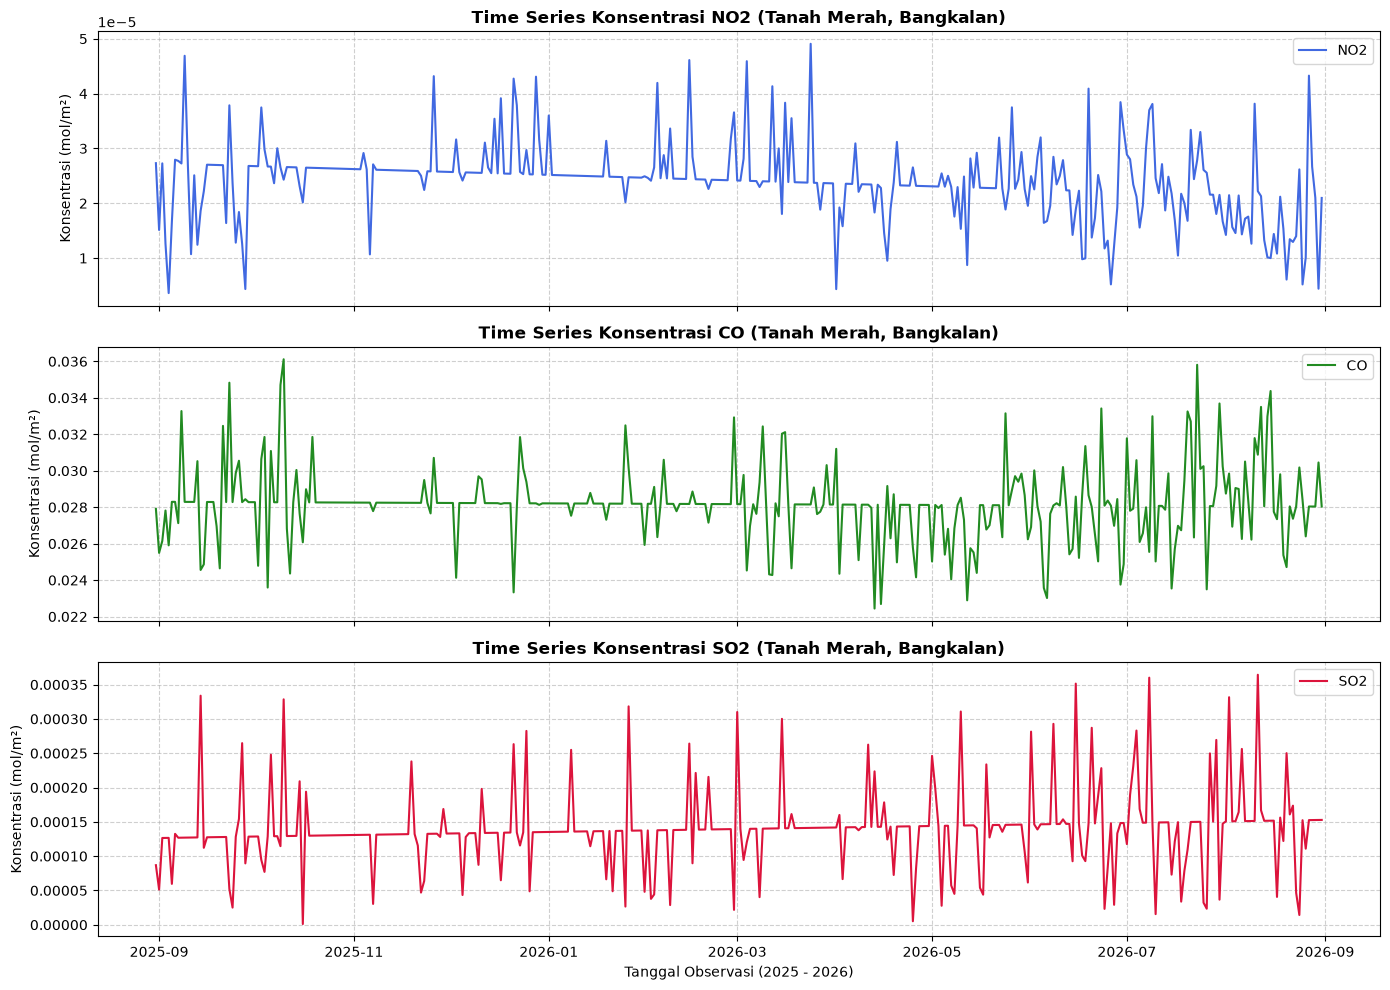


📋 5 BARIS PERTAMA TIME SERIES MULTIVARIAT (GABUNGAN 3 POLUTAN):


,NO2,CO,SO2
date,,,
2025-08-31,0.000027,0.027910,0.000087
2025-09-01,0.000015,0.025494,0.000051
2025-09-02,0.000027,0.026148,0.000126
2025-09-03,0.000013,0.027818,0.000127
2025-09-04,0.000004,0.025908,0.000127
2025-09-05,0.000017,0.028294,0.000060
2025-09-06,0.000028,0.028293,0.000133
2025-09-07,0.000028,0.027126,0.000127
2025-09-08,0.000027,0.033273,0.000127


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PEMBENTUKAN OBJEK DERET WAKTU (TIME SERIES) UNTUK SETIAP POLUTAN
# ==============================================================================

# 1. Membaca dataset bersih masing-masing polutan
df_no2 = pd.read_csv('NO2_TanahMerah_timeseries_clean.csv')
df_co  = pd.read_csv('CO_TanahMerah_timeseries_clean.csv')
df_so2 = pd.read_csv('SO2_TanahMerah_timeseries_clean.csv')
df_all = pd.read_csv('Polutan_Bangkalan.csv')

# 2. Konversi kolom 'date' ke tipe Datetime
for df in [df_no2, df_co, df_so2, df_all]:
    df['date'] = pd.to_datetime(df['date'])

# 3. Menjadikan 'date' sebagai DatetimeIndex dengan frekuensi harian ('D')
ts_no2 = df_no2.set_index('date')['NO2'].asfreq('D')
ts_co  = df_co.set_index('date')['CO'].asfreq('D')
ts_so2 = df_so2.set_index('date')['SO2'].asfreq('D')

# Time series multivariat (gabungan ketiga polutan)
ts_all = df_all.set_index('date')[['NO2', 'CO', 'SO2']].asfreq('D')

# 4. Menampilkan Informasi Struktur Time Series Masing-Masing Polutan
print("=" * 70)
print("📊 INFORMASI STRUKTUR OBJEK TIME SERIES (DATETIMEINDEX)")
print("=" * 70)
for name, ts in [('NO2', ts_no2), ('CO', ts_co), ('SO2', ts_so2)]:
    print(f"\n🔹 Polutan: {name}")
    print(f"   - Tipe Objek   : {type(ts)}")
    print(f"   - Tipe Indeks  : {type(ts.index)}")
    print(f"   - Rentang Waktu: {ts.index.min().strftime('%Y-%m-%d')} s/d {ts.index.max().strftime('%Y-%m-%d')}")
    print(f"   - Frekuensi    : {ts.index.freqstr} (Harian)")
    print(f"   - Total Sampel : {len(ts)} hari")
    print(f"   - 5 Nilai Awal : \n{ts.head()}")

# 5. Visualisasi Plot Deret Waktu (Time Series Plots) Masing-Masing Polutan
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot NO2
axes[0].plot(ts_no2.index, ts_no2.values, color='royalblue', linewidth=1.5, label='NO2')
axes[0].set_title('Time Series Konsentrasi NO2 (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Konsentrasi (mol/m²)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')

# Plot CO
axes[1].plot(ts_co.index, ts_co.values, color='forestgreen', linewidth=1.5, label='CO')
axes[1].set_title('Time Series Konsentrasi CO (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Konsentrasi (mol/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

# Plot SO2
axes[2].plot(ts_so2.index, ts_so2.values, color='crimson', linewidth=1.5, label='SO2')
axes[2].set_title('Time Series Konsentrasi SO2 (Tanah Merah, Bangkalan)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tanggal Observasi (2025 - 2026)')
axes[2].set_ylabel('Konsentrasi (mol/m²)')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# 6. Menampilkan DataFrame Gabungan Berbasis Time Series
print("\n" + "=" * 70)
print("📋 5 BARIS PERTAMA TIME SERIES MULTIVARIAT (GABUNGAN 3 POLUTAN):")
print("=" * 70)
display(ts_all.head(10))



---
# Ekstraksi Fitur TSFEL Multivariat (Gabungan Seluruh Polutan)

Pada tahap ini, dilakukan proses ekstraksi fitur deret waktu secara terintegrasi untuk ketiga polutan (**NO2**, **SO2**, dan **CO**) langsung dari file utama `Polutan_Bangkalan.csv` ke dalam satu kesatuan data fitur multivariat.

### Rincian Alur Pemrosesan pada Kode:
Proses dimulai dengan membaca data Polutan_Bangkalan.csv dan mengurutkannya berdasarkan tanggal agar data tersusun secara kronologis. Selanjutnya, digunakan 68 fitur TSFEL untuk menganalisis data dari tiga polutan, yaitu NO₂, SO₂, dan CO. Data kemudian dibersihkan dengan mengubah nilai yang tidak valid menjadi NaN, mendeteksi outlier menggunakan metode IQR, serta mengisi nilai yang hilang menggunakan interpolasi linear berbasis waktu. Setelah data bersih, 68 fitur TSFEL diekstraksi dari masing-masing polutan dan diberi nama sesuai jenis polutannya, seperti NO2_calc_mean dan CO_entropy. Hasil ekstraksi dari ketiga polutan kemudian digabungkan menjadi 204 fitur dan disimpan dalam file All-Pollutants-TanahMerah-TSFEL.csv untuk digunakan pada analisis atau pemodelan selanjutnya.


In [1]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
# Sesuaikan nama file jika berbeda (misal: 'mystorage/Kerek-Clean.csv')
df = pd.read_csv('./Polutan_Bangkalan.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


# Dictionary untuk menampung seluruh hasil ekstraksi dari semua polutan
combined_row = {}

# ---------- 3. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")
    
    # Buat copy dataframe agar tidak saling menimpa
    df_poly = df[['date', pollutant]].copy()

    # Paksa kolom target jadi numerik
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')
    n_missing_before = df_poly[pollutant].isna().sum()
    print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

    # Handling outlier dengan IQR
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 4. Simpan ke DataFrame final (1 baris, 204 kolom) ----------
extracted_features_final = pd.DataFrame([combined_row])

print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'All-Pollutants-TanahMerah-TSFEL.csv'
extracted_features_final.to_csv(output_filename, index=False)
print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 0

--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 0

--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 0

Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: All-Pollutants-TanahMerah-TSFEL.csv


In [4]:
import pandas as pd

df_feat = pd.read_csv("All-Pollutants-TanahMerah-TSFEL.csv")
df_feat.head()

,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid,NO2_calc_max,NO2_calc_mean,NO2_calc_median,NO2_calc_min,NO2_calc_std,...,CO_spectral_spread,CO_spectral_variation,CO_spectrogram_mean_coeff,CO_sum_abs_diff,CO_wavelet_abs_mean,CO_wavelet_energy,CO_wavelet_entropy,CO_wavelet_std,CO_wavelet_var,CO_zero_cross
0,2.182459e-07,0.008847,2.0,5.979340e-10,172.246914,0.000032,0.000024,0.000025,0.000016,0.000003,...,0.0473,0.887738,5.075082e-08,0.024626,0.001637,0.005975,1.969638,0.005736,0.000041,0.0
